In [5]:
import numpy as np
import pandas as pd



generating data

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# for reproducibility
np.random.seed(42)

# temperature range (°C)
temp = np.linspace(5, 45, 70)

# nonlinear crop yield pattern
# peaks around 25°C, then falls again
yield_ = -0.2*(temp - 25)**2 + 60 + np.random.normal(0, 3, 70)

# create dataframe
data = pd.DataFrame({'Temperature': temp, 'CropYield': yield_})
data.to_csv('crop_yield.csv', index=False)

In [7]:

data.head()

,Temperature,CropYield
0,5.000000,-18.509858
1,5.579710,-15.844325
2,6.159420,-9.050423
3,6.739130,-2.122782
4,7.318841,-3.227140


Visualization

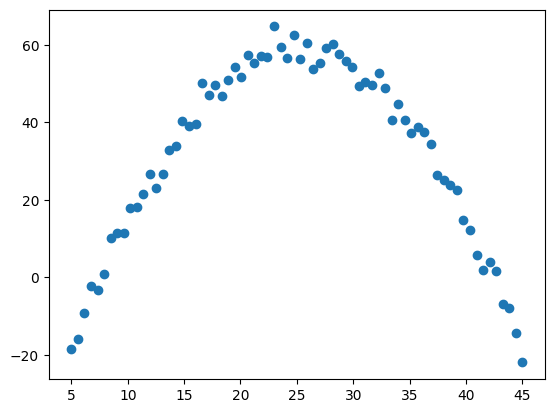

In [8]:
import matplotlib.pyplot as plt
plt.scatter(data['Temperature'],data['CropYield'])

Trainning a model

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(data[['Temperature']],data[['CropYield']],random_state=42)

In [41]:
X_train.head()

,Temperature
57,38.043478
47,32.246377
16,14.275362
34,24.710145
42,29.347826


In [11]:
from sklearn.linear_model import LinearRegression


applying Simple linear Regression

In [12]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Score of Linear regression

In [13]:
from sklearn.metrics import r2_score
r=r2_score(y_test,model.predict(X_test))

In [14]:
r

-0.09280072235826786

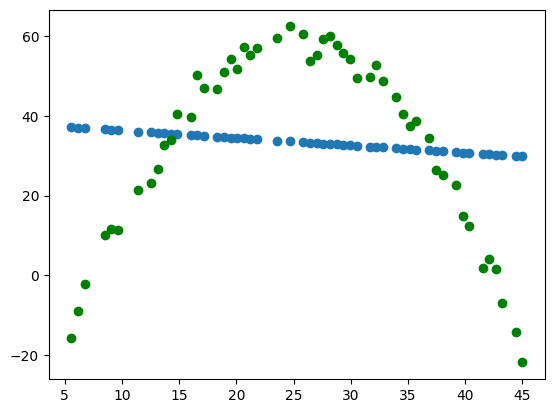

In [15]:
plt.scatter(X_train,model.predict(X_train))
plt.scatter(X_train,y_train,color='green')

Applying Polynomial regression

In [16]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)

In [17]:
X_poly=poly.fit_transform(X_train)
Xtest_poly=poly.fit_transform(X_test)

In [18]:
Xtest_poly

array([[1.00000000e+00, 1.77536232e+01, 3.15191136e+02],
       [1.00000000e+00, 5.00000000e+00, 2.50000000e+01],
       [1.00000000e+00, 3.34057971e+01, 1.11594728e+03],
       [1.00000000e+00, 7.31884058e+00, 5.35654274e+01],
       [1.00000000e+00, 3.63043478e+01, 1.31800567e+03],
       [1.00000000e+00, 1.54347826e+01, 2.38232514e+02],
       [1.00000000e+00, 1.07971014e+01, 1.16577400e+02],
       [1.00000000e+00, 2.41304348e+01, 5.82277883e+02],
       [1.00000000e+00, 3.10869565e+01, 9.66398866e+02],
       [1.00000000e+00, 1.19565217e+01, 1.42958412e+02],
       [1.00000000e+00, 2.29710145e+01, 5.27667507e+02],
       [1.00000000e+00, 1.02173913e+01, 1.04395085e+02],
       [1.00000000e+00, 4.38405797e+01, 1.92199643e+03],
       [1.00000000e+00, 7.89855072e+00, 6.23871035e+01],
       [1.00000000e+00, 4.09420290e+01, 1.67624974e+03],
       [1.00000000e+00, 2.23913043e+01, 5.01370510e+02],
       [1.00000000e+00, 3.86231884e+01, 1.49175068e+03],
       [1.00000000e+00, 2.52898

In [19]:
m1=model.fit(X_poly,y_train)

Score we get maximum accuracy

In [20]:
from sklearn.metrics import r2_score
r=r2_score(y_train,m1.predict(X_poly))
r

0.9880126195140028

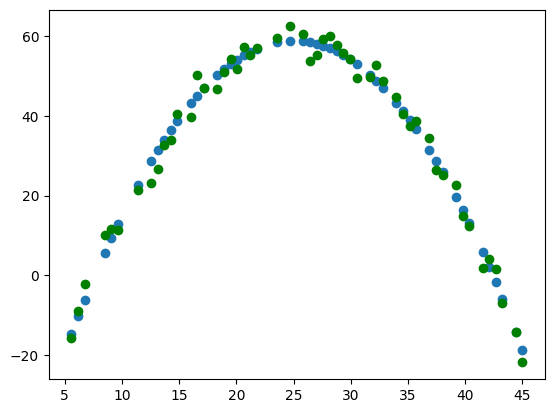

In [21]:
plt.scatter(X_train,m1.predict(X_poly))
plt.scatter(X_train,y_train,color='green')

In [22]:
m1.predict(Xtest_poly)

array([[ 48.63762242],
       [-19.13462421],
       [ 45.22259656],
       [ -2.10001356],
       [ 34.11821994],
       [ 41.02777975],
       [ 19.52491576],
       [ 58.76547645],
       [ 51.74990586],
       [ 25.68602909],
       [ 58.10214444],
       [ 16.24800976],
       [-10.06840724],
       [  1.83139022],
       [  9.54444048],
       [ 57.57412911],
       [ 22.87852665],
       [ 58.90521024]])

In [23]:
m1.score(Xtest_poly,y_test)

0.9888385581424036

In [24]:
m1.predict([[1,10,100]])

array([[14.98542247]])

Pipeline

In [25]:
from sklearn.pipeline import Pipeline

In [39]:
def poly_regression(degree):
    X_new=np.linspace(5, 45, 70).reshape(70,1)

    poly_feature= PolynomialFeatures(degree=degree , include_bias=True)
    lin_reg = LinearRegression()
    poly_regression= Pipeline([('poly_features',poly_feature),("lin_reg",lin_reg)])

    poly_regression.fit(X_train,y_train)
    y_pred_new= poly_regression.predict(X_new)

    plt.plot(X_new, y_pred_new,'r',label ="Degree" + str(degree))
    plt.scatter(X_train,y_train,color='green')

    plt.legend(loc='upper left')

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


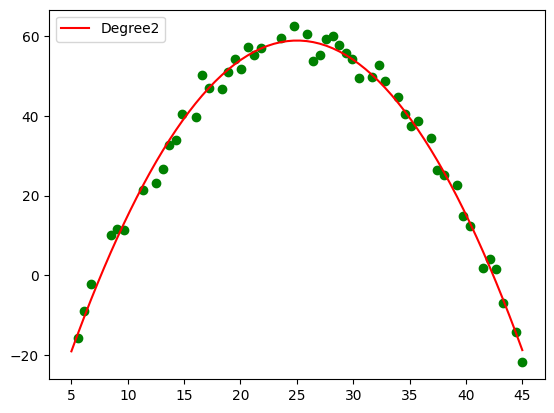

In [40]:
poly_regression(2)